### This notebook is for the quality control and overview on the MPRA done in NGN2
- /data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K
QC: How well is the replicate correlation (DNA, RNA, Ratio)? How many barcodes per sequence for tested vs positive and negative controls?
QC: How is the activity distribution of elements without alt, controls pos, negative and scrambled
QC: Correlation of control sequence activity (extract already tested values and check the correlation)

#### comparison of different alignment methods: 
- Technical paper: something went wrong
    - bbmap + strand sensitivity
        - label
        - cardiac_neuro_cava_random    17856
        - C_negative_neuron_NP           188
        - C_negative_neuron_MK           134
        - C_positive_neuron_NP            94
        - C_positive_neuron_CD            85
        - C_positive_neuron_MK            20

- bwa finest: 
    - label
    - cardiac_neuro_cava_random    72056
    - C_negative_neuron_MK           214
    - C_negative_neuron_NP           199
    - C_positive_neuron_NP            99
    - C_positive_neuron_MK            96
    - C_positive_neuron_CD            93



In [1]:
import ast
import pandas as pd
import numpy as np
import yaml
import os
from collections import defaultdict
from importlib import reload
import math # check for nan
import matplotlib.pyplot as plt # plt.show()
import seaborn as sns

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

### Quality control of the Metadata file: Mike feedback
- MK is marked as element but is scrambled


In [4]:
# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'


list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

In [5]:
metadata_path = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/mpra_metadata_format/MPRA_80215.metadata.tsv.gz"
mpra_80k_metadata_df = pd.read_csv(metadata_path, sep='\t', compression='gzip', low_memory=False)

# use safe eval on list
# Apply the safe_eval function to the specified columns
for col in list_columns:
    mpra_80k_metadata_df[col] = mpra_80k_metadata_df[col].apply(safe_eval)

In [6]:
mpra_80k_metadata_df.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info'],
      dtype='object')

In [7]:
mpra_80k_metadata_df['label'] = mpra_80k_metadata_df['name'].apply(hf.get_label)

In [8]:
mpra_80k_metadata_df['label'].value_counts()

label
cardiac_neuro_cava_random            73940
MK                                    2397
C_positive_heart_AB                    909
GC_Selvarajan                          358
GC_Vista                               256
C_negative_heart_MK                    243
C_negative_neuron_MK                   222
C_negative_neuron_NP                   217
GC_Mendelian_variants                  209
GC_Kircher                             203
C_SLEA                                 200
GC_Cort_Chengyu                        185
C_positive_heart_CAD                    99
C_positive_neuron_NP                    99
C_positive_heart_MK                     97
C_positive_neuron_MK                    96
C_positive_neuron_CD                    94
GC_Glut_Chengyu                         83
GC_DNase_positive_shuffeled             55
GC_Atrial_fib                           45
GC_GABA_Chengyu                         42
GC_DNase_positive                       41
GC_Mohlke                               38
GC_DN

### Change DNase data because the finalized MPRAsnakeflow results used initial design
- No: change the count files (you have to change 2 things and can still use the Metadata file)
- /home/kisa/coding/80K_MPRA/ismb/NGN2_neurons/reporter_experiment.barcode.NGN2.defaultAssignment.default.all.tsv.gz


In [ ]:
ngn2_count_table_path = "/home/kisa/coding/80K_MPRA/ismb/NGN2_neurons/reporter_experiment.barcode.NGN2.defaultAssignment.default.all.tsv.gz"
ngn2_count_table = pd.read_csv(ngn2_count_table_path, sep="\t")

In [98]:
ngn2_count_table_not_matching_pattern = ngn2_count_table.loc[ngn2_count_table['oligo_name'].str.contains("_.", regex=False)].copy()
# 'GC_DNase_negative_blood:chr10:16877280-16877549_active_count_12_3_.'
remaining_count_table = ngn2_count_table.loc[~ngn2_count_table['oligo_name'].str.contains("_.", regex=False)].copy()

In [99]:
# replace the _. with (.)
def add_bracket_pattern_to_oligo_name(header):
    return header.replace("_.", "(.)")

ngn2_count_table_not_matching_pattern['oligo_name'] = ngn2_count_table_not_matching_pattern['oligo_name'].apply(add_bracket_pattern_to_oligo_name)

renamed_count_table = pd.concat([ngn2_count_table_not_matching_pattern, remaining_count_table], ignore_index=True)

In [100]:
renamed_count_table

,barcode,oligo_name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3
0,TTGTTAAAGGGGAGG,GC_DNase_negative_blood:chr10:16877280-1687754...,1.0,8.0,3.0,1.0,2.0,2.0
1,GTTCGTCTAAGTTTG,GC_DNase_negative_blood:chr10:16877280-1687754...,13.0,20.0,4.0,22.0,3.0,32.0
2,GACGCCCAGCCGCTG,GC_DNase_negative_blood:chr10:16877280-1687754...,2.0,8.0,2.0,2.0,1.0,6.0
3,TGTCGTCTCCGCTCG,GC_DNase_negative_blood:chr10:16877280-1687754...,1.0,7.0,3.0,11.0,4.0,8.0
4,TCGCGCATCACGACG,GC_DNase_negative_blood:chr10:16877280-1687754...,4.0,14.0,1.0,8.0,6.0,9.0
...,...,...,...,...,...,...,...,...
6370543,GGGGATGCGGTAGGA,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,7.0,13.0,6.0,17.0,6.0,10.0
6370544,ATGTAAAGACCCCCC,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,4.0,20.0,7.0,24.0,7.0,18.0
6370545,GATCGACGTTTTTAA,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,1.0,14.0,5.0,15.0,4.0,9.0
6370546,ACTATGTTATCCAAC,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,NaN,NaN,4.0,10.0,2.0,5.0


In [101]:
output_path = "/home/kisa/coding/80K_MPRA/ismb/NGN2_neurons/renamed_reporter_experiment.barcode.NGN2.defaultAssignment.default.all.tsv.gz"
renamed_count_table.to_csv(output_path, sep="\t", index=False)

In [ ]:
# GC_DNase_negative_blood:chr10:16877280-16877549

# # metadata:
# GC_DNase_negative_blood:chr10:16877280-16877549_active_count_12_3(.)

Same for undifferenciated WTC11

In [3]:
import pandas as pd

In [4]:
undiff_wtc11_count_table_path = "/home/kisa/coding/80K_MPRA/ismb/undiff_WTC11/reporter_experiment.barcode.WTC11.defaultAssignment.default.all.tsv.gz"
output_path = "/home/kisa/coding/80K_MPRA/ismb/undiff_WTC11/renamed_reporter_experiment.barcode.WTC11.defaultAssignment.default.all.tsv.gz"

undiff_wtc11_count_table = pd.read_csv(undiff_wtc11_count_table_path, sep="\t")
undiff_wtc11_count_table_not_matching_pattern = undiff_wtc11_count_table.loc[undiff_wtc11_count_table['oligo_name'].str.contains("_.", regex=False)].copy()
# 'GC_DNase_negative_blood:chr10:16877280-16877549_active_count_12_3_.'
remaining_count_table = undiff_wtc11_count_table.loc[~undiff_wtc11_count_table['oligo_name'].str.contains("_.", regex=False)].copy()
# replace the _. with (.)
def add_bracket_pattern_to_oligo_name(header):
    return header.replace("_.", "(.)")

undiff_wtc11_count_table_not_matching_pattern['oligo_name'] = undiff_wtc11_count_table_not_matching_pattern['oligo_name'].apply(add_bracket_pattern_to_oligo_name)

renamed_count_table = pd.concat([undiff_wtc11_count_table_not_matching_pattern, remaining_count_table], ignore_index=True)
renamed_count_table
renamed_count_table.to_csv(output_path, sep="\t", index=False)

#### Generate label file

In [ ]:
mpra_80k_metadata_df['label'].value_counts()
def get_scramble_label(name):
    if "scramble_negative" in name:
        return "scramble_ctrl"
    if "negative_neuron" in name:
        return "negative_neuron_ctrl"
    return name.split(":")[0]


# add a scramble_control label
mpra_80k_metadata_df['label'] = mpra_80k_metadata_df['name'].apply(get_scramble_label)


In [116]:
negative_ctrls = mpra_80k_metadata_df.loc[mpra_80k_metadata_df['label'] == "negative_neuron_ctrl"]
negative_ctrls

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info,label
76929,C_negative_neuron_MK:tile_14444_chr15_67066278...,CTCAAGAAGACGGGGCAGCTGGACGAGCTGGAGAAGGCCATCACCA...,element,element inactive control,Michael Kosicki,GRCh38,chr15,67066277.0,67066547.0,+,None,None,None,None,NaN,negative_neuron_ctrl
76930,C_negative_neuron_MK:tile_9599_chr12_65742272_...,AGCCCGCCCGCGCCGCACGGTGGCCCCTTGCGCTGGCCTGATCGTG...,element,element inactive control,Michael Kosicki,GRCh38,chr12,65742271.0,65742541.0,+,None,None,None,None,NaN,negative_neuron_ctrl
76931,C_negative_neuron_MK:tile_9256_chr12_26114182_...,GGGTGTCGACCTTCGCGTAACCCGCGCCCAGGAGGGCCGCTCGGAA...,element,element inactive control,Michael Kosicki,GRCh38,chr12,26114181.0,26114451.0,+,None,None,None,None,NaN,negative_neuron_ctrl
76932,C_negative_neuron_MK:tile_44145_chr8_80578146_...,TGCCGCTTCCGAGGGCTCCTCTCGCCAAGGGAGAGAGCCCTAGACC...,element,element inactive control,Michael Kosicki,GRCh38,chr8,80578145.0,80578415.0,+,None,None,None,None,NaN,negative_neuron_ctrl
76933,C_negative_neuron_MK:tile_1999_chr1_88462556_8...,CATCAAGCCGCGCTCTCTCATTAATCTGCTCTTGCAAATCAGCACC...,element,element inactive control,Michael Kosicki,GRCh38,chr1,88462555.0,88462825.0,+,None,None,None,None,NaN,negative_neuron_ctrl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80084,C_negative_heart_MK:tile_36139_chr6_17473756_1...,TTCTATATTTGTATGTGCTGGGGGGTGGATCACATGACAAAACCAT...,element,element inactive control,general controls IGVF year 1 design 2023,GRCh38,chr6,17473755.0,17474025.0,+,None,None,None,None,NaN,negative_neuron_ctrl
80085,C_negative_neuron_MK:tile_22146_chr2_72898113_...,TTGCAGGCTTTCAGCTGTTACCTCAGTCCCTCCTCGCCTCATTCCC...,element,element inactive control,Michael Kosicki,GRCh38,chr2,72898112.0,72898382.0,+,None,None,None,None,NaN,negative_neuron_ctrl
80086,C_negative_heart_MK:tile_37605_chr6_111550485_...,TTGCTGTGAAAGCTGTGATGTTATCAGTGACTTCTGAGGGGTGTTT...,element,element inactive control,general controls IGVF year 1 design 2023,GRCh38,chr6,111550484.0,111550754.0,+,None,None,None,None,NaN,negative_neuron_ctrl
80087,C_negative_heart_MK:tile_8033_chr11_69157415_6...,TTTGCAGATTACGTCAGCGCTGGCGAGCAGGGGGCGCGGGGACAGC...,element,element inactive control,general controls IGVF year 1 design 2023,GRCh38,chr11,69157414.0,69157684.0,+,None,None,None,None,NaN,negative_neuron_ctrl


In [ ]:
negative_ctrls

In [113]:
mpra_80k_metadata_df['label'].value_counts()

label
cardiac_neuro_cava_random            73940
MK                                    1897
C_positive_heart_AB                    909
scramble_control                       500
negative_neuron_control                451
GC_Selvarajan                          358
GC_Vista                               256
C_negative_heart_MK                    231
GC_Mendelian_variants                  209
GC_Kircher                             203
C_SLEA                                 200
GC_Cort_Chengyu                        185
C_positive_heart_CAD                    99
C_positive_neuron_NP                    99
C_positive_heart_MK                     97
C_positive_neuron_MK                    96
C_positive_neuron_CD                    94
GC_Glut_Chengyu                         83
GC_DNase_positive_shuffeled             55
GC_Atrial_fib                           45
GC_GABA_Chengyu                         42
GC_DNase_positive                       41
GC_Mohlke                               38
GC_DN

In [117]:
mpra_80k_metadata_df[['name', 'label']].to_csv("/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/test_mpralib_output/80k_metadata_scramble_control_label.tsv", sep="\t", index=False, header=False)

### Change MK data

In [9]:
mk_metadata = mpra_80k_metadata_df.loc[mpra_80k_metadata_df['label'] == "MK"]

In [10]:
mk_metadata[col_category].value_counts()

category
variant      1299
element       598
scrambled     500
Name: count, dtype: int64

### Use the already updated version of the MK controls (associated genomic regions)
- Found one sequence without genomic regions => add it
- Split into variant specific groups

In [12]:
mk_elements_fa = hf.fasta_to_dataframe("/home/kisa/coding/80K_MPRA/80K-Analysis/07_quality_control/notebooks/control_metadata/MK_element_region_hg38.fa", columns=['name', 'bed_sequence'])
mk_elements_fa['bed_sequence'] = mk_elements_fa['bed_sequence'].str.upper()

mk_elements_fa["name"] = mk_elements_fa["name"].apply(lambda name: name.split("(")[0])
mk_elements_fa


mk_metadata_regions_elements = mk_metadata.loc[~(mk_metadata[col_category] == "variant")].copy() # 1,057 (only alt) 1,299  with ref


hg38_designed_seq_mk = mk_elements_fa.merge(mk_metadata_regions_elements, on="name", how="inner").copy()

In [15]:
metadata_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/07_quality_control/notebooks/control_metadata/MPRA_80215_updated_dnase_sequences.metadata.tsv.gz"
updated_mpra_80k_metadata_df = pd.read_csv(metadata_path, sep='\t', compression='gzip', low_memory=False)

# use safe eval on list
# Apply the safe_eval function to the specified columns
for col in list_columns:
    updated_mpra_80k_metadata_df[col] = updated_mpra_80k_metadata_df[col].apply(safe_eval)

In [20]:
updated_mpra_80k_metadata_df_mk = updated_mpra_80k_metadata_df.loc[updated_mpra_80k_metadata_df['name'].str.startswith("MK:")].copy()
updated_mpra_80k_metadata_df_mk


,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
0,MK:rdhs_664198|chr8-10365156+10365425|reference,AAAAAAAAAGTCGAGACTGGAAGAAGCAAACTTTCAGCTAATTATC...,variant,element active control,Michael Kosicki,GRCh38,chr8,10365155.0,10365425.0,+,"[SNV, SNV, SNV, SNV, SNV, SNV, indel, indel, i...","[20, 252, 20, 252, 36, 36, 17, 249, 33]",None,"[ref, ref, ref, ref, ref, ref, ref, ref, ref]",NaN
1,MK:tile_47691|chr20-20492859+20493129|reference,AAAAAAAATTTGCAAATCATTGCCTGGTTGCCAAGCAGGGAGATAA...,variant,element active control,Michael Kosicki,GRCh38,chr20,20492858.0,20493129.0,+,[SNV],[40],None,[ref],NaN
2,MK:tile_47699|chr22-42282878+42283148|reference,AAAAAGGGAGGGCCAAATAAAGCCCCACGCCGCCCAGCACGGGCTC...,variant,element active control,Michael Kosicki,GRCh38,chr22,42282877.0,42283148.0,+,[SNV],[172],None,[ref],NaN
3,MK:tile_38401|chr7-1226231+1226500|reference,AAAACTATTAGACGACAGGCGGATGTGCTACTAAAACTCTTGGTTA...,variant,element active control,Michael Kosicki,GRCh38,chr7,1226230.0,1226500.0,+,"[SNV, SNV, SNV, SNV, indel, indel]","[84, 84, 248, 248, 245, 81]",None,"[ref, ref, ref, ref, ref, ref]",NaN
4,MK:tile_47638|chr16-52435608+52435878|reference,AAAAGCCACCCCAGCTCTCCACTTTCCCATCCGATTCTAGTAGGTC...,variant,element active control,Michael Kosicki,GRCh38,chr16,52435607.0,52435878.0,+,[SNV],[0],None,[ref],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2392,MK:tile_2240|chr1-116244322+116244591|scramble...,CTTAATCAAATAACCCATTAATTCTATATATCTACCTAATATTAAT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr1,116244321.0,116244591.0,+,None,None,None,None,NaN
2393,MK:tile_6675|chr11-2374617+2374886|scramble_ne...,CATCGGCCCTGGTGAAGCGTCCGTCCAGACGGGCCTGCCTAGCCTC...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr11,2374616.0,2374886.0,+,None,None,None,None,NaN
2394,MK:tile_18415|chr17-71181691+71181960|scramble...,TAAATATTCAGCGATACATTCCTATTCTTTTTCAGAAGTAGTTATT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr17,71181690.0,71181960.0,+,None,None,None,None,NaN
2395,MK:tile_14356|chr15-67031618+67031887|scramble...,TGAAGCCCCTGATTCTGTTAGAATAAGGTTACTGAGTCGTGTATAC...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr15,67031617.0,67031887.0,+,None,None,None,None,NaN


In [21]:
updated_mpra_80k_metadata_df_mk_nona = updated_mpra_80k_metadata_df_mk.loc[~updated_mpra_80k_metadata_df_mk['start'].isna()].copy()
updated_mpra_80k_metadata_df_mk_na = updated_mpra_80k_metadata_df_mk.loc[updated_mpra_80k_metadata_df_mk['start'].isna()].copy()

# Extract chromosome, start, and end coordinates
updated_mpra_80k_metadata_df_mk_na['chr'] = 'chr4'
updated_mpra_80k_metadata_df_mk_na['start'] = '165327321'
updated_mpra_80k_metadata_df_mk_na['end'] = '165327591'
updated_mpra_80k_metadata_df_mk_na['strand'] = '+'
updated_mpra_80k_metadata_df_mk_na['category'] = 'element'

updated_mpra_80k_metadata_df_mk_updated = pd.concat([updated_mpra_80k_metadata_df_mk_na, updated_mpra_80k_metadata_df_mk_nona], ignore_index=True)

/tmp/ipykernel_4425/3870613176.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  updated_mpra_80k_metadata_df_mk_updated = pd.concat([updated_mpra_80k_metadata_df_mk_na, updated_mpra_80k_metadata_df_mk_nona], ignore_index=True)


In [22]:
updated_mpra_80k_metadata_df_mk_updated

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
0,MK:rdhs_664198|chr8-10365156+10365425|reference,AAAAAAAAAGTCGAGACTGGAAGAAGCAAACTTTCAGCTAATTATC...,variant,element active control,Michael Kosicki,GRCh38,chr8,10365155.0,10365425.0,+,"[SNV, SNV, SNV, SNV, SNV, SNV, indel, indel, i...","[20, 252, 20, 252, 36, 36, 17, 249, 33]",None,"[ref, ref, ref, ref, ref, ref, ref, ref, ref]",NaN
1,MK:tile_47691|chr20-20492859+20493129|reference,AAAAAAAATTTGCAAATCATTGCCTGGTTGCCAAGCAGGGAGATAA...,variant,element active control,Michael Kosicki,GRCh38,chr20,20492858.0,20493129.0,+,[SNV],[40],None,[ref],NaN
2,MK:tile_47699|chr22-42282878+42283148|reference,AAAAAGGGAGGGCCAAATAAAGCCCCACGCCGCCCAGCACGGGCTC...,variant,element active control,Michael Kosicki,GRCh38,chr22,42282877.0,42283148.0,+,[SNV],[172],None,[ref],NaN
3,MK:tile_38401|chr7-1226231+1226500|reference,AAAACTATTAGACGACAGGCGGATGTGCTACTAAAACTCTTGGTTA...,variant,element active control,Michael Kosicki,GRCh38,chr7,1226230.0,1226500.0,+,"[SNV, SNV, SNV, SNV, indel, indel]","[84, 84, 248, 248, 245, 81]",None,"[ref, ref, ref, ref, ref, ref]",NaN
4,MK:tile_47638|chr16-52435608+52435878|reference,AAAAGCCACCCCAGCTCTCCACTTTCCCATCCGATTCTAGTAGGTC...,variant,element active control,Michael Kosicki,GRCh38,chr16,52435607.0,52435878.0,+,[SNV],[0],None,[ref],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2392,MK:tile_2240|chr1-116244322+116244591|scramble...,CTTAATCAAATAACCCATTAATTCTATATATCTACCTAATATTAAT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr1,116244321.0,116244591.0,+,None,None,None,None,NaN
2393,MK:tile_6675|chr11-2374617+2374886|scramble_ne...,CATCGGCCCTGGTGAAGCGTCCGTCCAGACGGGCCTGCCTAGCCTC...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr11,2374616.0,2374886.0,+,None,None,None,None,NaN
2394,MK:tile_18415|chr17-71181691+71181960|scramble...,TAAATATTCAGCGATACATTCCTATTCTTTTTCAGAAGTAGTTATT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr17,71181690.0,71181960.0,+,None,None,None,None,NaN
2395,MK:tile_14356|chr15-67031618+67031887|scramble...,TGAAGCCCCTGATTCTGTTAGAATAAGGTTACTGAGTCGTGTATAC...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr15,67031617.0,67031887.0,+,None,None,None,None,NaN


#### Focus on variants and add SPDI
- normal case with | variant info
- ts case
- LC case

Only alternatives: 

In [70]:
# split the given mk data into the variants => ts, LC and normal variants => compute SPDIs for the easy case and use MKs table for the harder cases

# variants: not reference + not |ts in name
variant_updated_mpra_80k_metadata_df_mk = updated_mpra_80k_metadata_df_mk.loc[(~updated_mpra_80k_metadata_df_mk['name'].str.contains("reference"))&(~updated_mpra_80k_metadata_df_mk['name'].str.contains("scramble_negative"))].copy()
variant_updated_mpra_80k_metadata_df_mk

ts_variant_updated_mpra_80k_metadata_df_mk = variant_updated_mpra_80k_metadata_df_mk.loc[variant_updated_mpra_80k_metadata_df_mk['name'].str.contains("|ts", regex=False)].copy()
ts_variant_updated_mpra_80k_metadata_df_mk

lc_variant_updated_mpra_80k_metadata_df_mk = variant_updated_mpra_80k_metadata_df_mk.loc[variant_updated_mpra_80k_metadata_df_mk['name'].str.contains("LC", regex=False)].copy()
lc_variant_updated_mpra_80k_metadata_df_mk

snp_variant_updated_mpra_80k_metadata_df_mk = variant_updated_mpra_80k_metadata_df_mk.loc[(~variant_updated_mpra_80k_metadata_df_mk['name'].str.contains("|ts", regex=False))&(~variant_updated_mpra_80k_metadata_df_mk['name'].str.contains("|LC", regex=False))].copy()
snp_variant_updated_mpra_80k_metadata_df_mk

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
242,MK:newcore_110746|chr13-80235318+80235587|G-A-21,GCTTCTAGTCATAGACAATGACAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[SNV],[20],None,[alt],NaN
243,MK:newcore_110746|chr13-80235318+80235587|G-C-21,GCTTCTAGTCATAGACAATGCCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[SNV],[20],None,[alt],NaN
244,MK:newcore_110746|chr13-80235318+80235587|T-A-197,GCTTCTAGTCATAGACAATGGCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[SNV],[196],None,[alt],NaN
245,MK:newcore_110746|chr13-80235318+80235587|T-A-265,GCTTCTAGTCATAGACAATGGCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[SNV],[264],None,[alt],NaN
246,MK:newcore_110746|chr13-80235318+80235587|T-A-9,GCTTCTAGACATAGACAATGGCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[SNV],[8],None,[alt],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266,MK:tile_985|chr1-33363965+33364235|T-C-94,TCTTAGGCTCTGTTCTCCGCCCCTTACTCCCCTCCCCCACCTGCTC...,variant,variant positive control,Michael Kosicki,GRCh38,chr1,33363964.0,33364235.0,+,[SNV],[93],None,None,NaN
1293,MK:tile_9894|chr12-94535162+94535431|A-G-113,CTAATGAAGGGGGCGATTCCCTGTCTCCGCTATGAAAAGAAAAATG...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,94535161.0,94535431.0,+,[SNV],[112],None,[alt],NaN
1294,MK:tile_9894|chr12-94535162+94535431|A-T-113,CTAATGAAGGGGGCGATTCCCTGTCTCCGCTATGAAAAGAAAAATG...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,94535161.0,94535431.0,+,[SNV],[112],None,[alt],NaN
1295,MK:tile_9894|chr12-94535162+94535431|G-A-105,CTAATGAAGGGGGCGATTCCCTGTCTCCGCTATGAAAAGAAAAATG...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,94535161.0,94535431.0,+,[SNV],[104],None,[alt],NaN


In [71]:
ts_variant_updated_mpra_80k_metadata_df_mk

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
250,MK:newcore_110746|chr13-80235318+80235587|ts18-24,GCTTCTAGTCATAGACAGCAATGGTTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[indel],[17],None,[alt],for start and end (1-based) of the variant see...
251,MK:newcore_110746|chr13-80235318+80235587|ts19...,GCTTCTAGTCATAGACAATGGCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[indel],[193],None,[alt],for start and end (1-based) of the variant see...
252,MK:newcore_110746|chr13-80235318+80235587|ts26...,GCTTCTAGTCATAGACAATGGCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[indel],[261],None,[alt],for start and end (1-based) of the variant see...
253,MK:newcore_110746|chr13-80235318+80235587|ts6-12,GCTTCCGACTGCAGACAATGGCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[indel],[5],None,[alt],for start and end (1-based) of the variant see...
258,MK:newcore_110751|chr13-80276302+80276571|ts14...,TTCCCAAATGCGTGCATTCTCACCCAGGCTGACTGTTCTTTTCTAC...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80276301.0,80276571.0,+,[indel],[141],None,[alt],for start and end (1-based) of the variant see...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1172,MK:tile_5101|chr10-75967401+75967670|ts173-179,ATTAAGAGAGTCCCAGGAGTTTCCAGGCTGTAAAAACCTAAATTGT...,variant,variant positive control,Michael Kosicki,GRCh38,chr10,75967400.0,75967670.0,+,[indel],[172],None,[alt],for start and end (1-based) of the variant see...
1173,MK:tile_5101|chr10-75967401+75967670|ts210-216,ATTAAGAGAGTCCCAGGAGTTTCCAGGCTGTAAAAACCTAAATTGT...,variant,variant positive control,Michael Kosicki,GRCh38,chr10,75967400.0,75967670.0,+,[indel],[209],None,[alt],for start and end (1-based) of the variant see...
1176,MK:tile_7158|chr11-16403072+16403341|ts218-224,CTTTTAACTCATAAGCTCAAAAGCTGGTAGTCTAACTGGCTGCCCT...,variant,variant positive control,Michael Kosicki,GRCh38,chr11,16403071.0,16403341.0,+,[indel],[217],None,[alt],for start and end (1-based) of the variant see...
1297,MK:tile_9894|chr12-94535162+94535431|ts102-108,CTAATGAAGGGGGCGATTCCCTGTCTCCGCTATGAAAAGAAAAATG...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,94535161.0,94535431.0,+,[indel],[101],None,[alt],for start and end (1-based) of the variant see...


In [72]:
lc_variant_updated_mpra_80k_metadata_df_mk

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
490,MK:tile_10173|chr12-113932853+113933122|LC18.1,ATGGAACAAATCAAGAAAAACCAAGAGAGGCAGGGGGGTCACATCC...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,113932852.0,113933122.0,+,[indel],[0],None,[alt],The meaning of LC was not known while generati...
491,MK:tile_10173|chr12-113932853+113933122|LC18.10,GCAAGGTGGGCTGGAGGGGGTTGGGAGAGGCAGGGGAACTGTGCTT...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,113932852.0,113933122.0,+,[indel],[60],None,[alt],The meaning of LC was not known while generati...
492,MK:tile_10173|chr12-113932853+113933122|LC18.11,GCAAGGTGGGCTGGAGGGGGTTGGGAGAGGCAGGGGAACTGTGCTT...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,113932852.0,113933122.0,+,[indel],[60],None,[alt],The meaning of LC was not known while generati...
493,MK:tile_10173|chr12-113932853+113933122|LC18.12,GCAAGGTGGGCTGGAGGGGGTTGGAGAGAATGAAAAAACTGTGCTT...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,113932852.0,113933122.0,+,[indel],[24],None,[alt],The meaning of LC was not known while generati...
494,MK:tile_10173|chr12-113932853+113933122|LC18.13,GCAAGGTGGGCTGGAGGGGGTTGGGAGAGGCAGGGGAACTGTGCTT...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,113932852.0,113933122.0,+,[indel],[48],None,[alt],The meaning of LC was not known while generati...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1288,MK:tile_985|chr1-33363966+33364235|LC28t5,TCTTAGGCTCTGTTCTCCGCCCCTTACTCCCCTCCCCCACCTGCTC...,variant,variant positive control,Michael Kosicki,GRCh38,chr1,33363965.0,33364235.0,+,[indel],[62],None,[alt],The meaning of LC was not known while generati...
1289,MK:tile_985|chr1-33363966+33364235|LC28t6,TCTTAGGCTCTGTTCTCCGCCCCTTACTCCCCTCCCCCACCTGCTC...,variant,variant positive control,Michael Kosicki,GRCh38,chr1,33363965.0,33364235.0,+,[indel],[74],None,[alt],The meaning of LC was not known while generati...
1290,MK:tile_985|chr1-33363966+33364235|LC28t7,TCTTAGGCTCTGTTCTCCGCCCCTTACTCCCCTCCCCCACCTGCTC...,variant,variant positive control,Michael Kosicki,GRCh38,chr1,33363965.0,33364235.0,+,[indel],[86],None,[alt],The meaning of LC was not known while generati...
1291,MK:tile_985|chr1-33363966+33364235|LC28t8,TCTTAGGCTCTGTTCTCCGCCCCTTACTCCCCTCCCCCACCTGCTC...,variant,variant positive control,Michael Kosicki,GRCh38,chr1,33363965.0,33364235.0,+,[indel],[98],None,[alt],The meaning of LC was not known while generati...


In [26]:
snp_variant_updated_mpra_80k_metadata_df_mk

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
242,MK:newcore_110746|chr13-80235318+80235587|G-A-21,GCTTCTAGTCATAGACAATGACAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[SNV],[20],None,[alt],NaN
243,MK:newcore_110746|chr13-80235318+80235587|G-C-21,GCTTCTAGTCATAGACAATGCCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[SNV],[20],None,[alt],NaN
244,MK:newcore_110746|chr13-80235318+80235587|T-A-197,GCTTCTAGTCATAGACAATGGCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[SNV],[196],None,[alt],NaN
245,MK:newcore_110746|chr13-80235318+80235587|T-A-265,GCTTCTAGTCATAGACAATGGCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[SNV],[264],None,[alt],NaN
246,MK:newcore_110746|chr13-80235318+80235587|T-A-9,GCTTCTAGACATAGACAATGGCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[SNV],[8],None,[alt],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266,MK:tile_985|chr1-33363965+33364235|T-C-94,TCTTAGGCTCTGTTCTCCGCCCCTTACTCCCCTCCCCCACCTGCTC...,variant,variant positive control,Michael Kosicki,GRCh38,chr1,33363964.0,33364235.0,+,[SNV],[93],None,None,NaN
1293,MK:tile_9894|chr12-94535162+94535431|A-G-113,CTAATGAAGGGGGCGATTCCCTGTCTCCGCTATGAAAAGAAAAATG...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,94535161.0,94535431.0,+,[SNV],[112],None,[alt],NaN
1294,MK:tile_9894|chr12-94535162+94535431|A-T-113,CTAATGAAGGGGGCGATTCCCTGTCTCCGCTATGAAAAGAAAAATG...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,94535161.0,94535431.0,+,[SNV],[112],None,[alt],NaN
1295,MK:tile_9894|chr12-94535162+94535431|G-A-105,CTAATGAAGGGGGCGATTCCCTGTCTCCGCTATGAAAAGAAAAATG...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,94535161.0,94535431.0,+,[SNV],[104],None,[alt],NaN


In [76]:
import re
## create SPDI
# dict of chr number to refseq chromosome number
chrom_2_refseq = {"chr1": "NC_000001.11",
    "chr2": "NC_000002.12",
    "chr3": "NC_000003.12",
    "chr4": "NC_000004.12",
    "chr5": "NC_000005.10",
    "chr6": "NC_000006.12",
    "chr7": "NC_000007.14",
    "chr8": "NC_000008.11",
    "chr9": "NC_000009.12",
    "chr10": "NC_000010.11",
    "chr11": "NC_000011.10",
    "chr12": "NC_000012.12",
    "chr13": "NC_000013.11",
    "chr14": "NC_000014.9",
    "chr15": "NC_000015.10",
    "chr16": "NC_000016.10",
    "chr17": "NC_000017.11",
    "chr18": "NC_000018.10",
    "chr19": "NC_000019.10",
    "chr20": "NC_000020.11",
    "chr21": "NC_000021.9",
    "chr22": "NC_000022.11",
    "chrX": "NC_000023.11",
    "chrY": "NC_000024.10"}

def mk_get_spdi(row, col_name, col_start, col_strand, col_chr):

    snp_header = row[col_name]
    # check for the expected string pattern
    variant_pattern = r"\|([A-Z])-([A-Z])-(\d+)"
    variant_match = re.search(pattern=variant_pattern, string=snp_header)
    if not bool(variant_match):
        raise ValueError("The expected variant information is not in the header")
    variant_REF, variant_ALT, one_based_pos = variant_match.groups()
    variant_POS = int(row[col_start]) + int(one_based_pos) - 1
    if row[col_strand] == "-":
        raise ValueError("For the minus strand I need to check if Michael Kosicki made the variant position strand aware")

    return f"{chrom_2_refseq[row[col_chr]]}:{variant_POS}:{variant_REF}:{variant_ALT}"


In [77]:
snp_variant_updated_mpra_80k_metadata_df_mk['SPDI'] = snp_variant_updated_mpra_80k_metadata_df_mk.apply(lambda row: mk_get_spdi(row, col_name=col_name, col_start=col_start, col_strand=col_strand, col_chr=col_chr), axis=1)

add spdi to ts variants

In [83]:
mk_table_spdi = pd.read_csv("/home/kisa/coding/80K_MPRA/metadata_info/MK/2024-10-21_spdi_collapse.tsv.gz", sep="\t")
mk_table_spdi.columns = ['name', 'SPDI']
mk_table_spdi

,name,SPDI
0,newcore_110746|chr13-80235318+80235587|ts18-24,NC_000013.11:80235334:ATGGCAA:GCAATGG
1,newcore_110746|chr13-80235318+80235587|ts194-200,NC_000013.11:80235510:CGATTGT:TAGCCAC
2,newcore_110746|chr13-80235318+80235587|ts262-268,NC_000013.11:80235578:CCTTATT:TTCCGCC
3,newcore_110746|chr13-80235318+80235587|ts6-12,NC_000013.11:80235322:TAGTCAT:CGACTGC
4,newcore_110751|chr13-80276302+80276571|ts142-148,NC_000013.11:80276442:CATCCAT:TGCTTGC
...,...,...
255,tile_985|chr1-33363966+33364235|LC28t7,NC_000001.11:33364051:CAGAGCCTGAAG:TGAGATTCAGGA
256,tile_985|chr1-33363966+33364235|LC28t8,NC_000001.11:33364063:AAGCCGGTTGCC:GGATTAACCATT
257,tile_985|chr1-33363966+33364235|LC28t9,NC_000001.11:33364075:AAGGTGACAGGA:GGAACAGTGAAG
258,tile_9894|chr12-94535162+94535431|ts102-108,NC_000012.12:94535262:GTTGCCA:ACCATTG


In [ ]:
ts_variant_updated_mpra_80k_metadata_df_mk.drop(columns=["SPDI"])
ts_variant_updated_mpra_80k_metadata_df_mk

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
250,MK:newcore_110746|chr13-80235318+80235587|ts18-24,GCTTCTAGTCATAGACAGCAATGGTTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[indel],[17],None,[alt],for start and end (1-based) of the variant see...
251,MK:newcore_110746|chr13-80235318+80235587|ts19...,GCTTCTAGTCATAGACAATGGCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[indel],[193],None,[alt],for start and end (1-based) of the variant see...
252,MK:newcore_110746|chr13-80235318+80235587|ts26...,GCTTCTAGTCATAGACAATGGCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[indel],[261],None,[alt],for start and end (1-based) of the variant see...
253,MK:newcore_110746|chr13-80235318+80235587|ts6-12,GCTTCCGACTGCAGACAATGGCAATTGCAGAGCAAGACTAATAACA...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80235317.0,80235587.0,+,[indel],[5],None,[alt],for start and end (1-based) of the variant see...
258,MK:newcore_110751|chr13-80276302+80276571|ts14...,TTCCCAAATGCGTGCATTCTCACCCAGGCTGACTGTTCTTTTCTAC...,variant,variant positive control,Michael Kosicki,GRCh38,chr13,80276301.0,80276571.0,+,[indel],[141],None,[alt],for start and end (1-based) of the variant see...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1172,MK:tile_5101|chr10-75967401+75967670|ts173-179,ATTAAGAGAGTCCCAGGAGTTTCCAGGCTGTAAAAACCTAAATTGT...,variant,variant positive control,Michael Kosicki,GRCh38,chr10,75967400.0,75967670.0,+,[indel],[172],None,[alt],for start and end (1-based) of the variant see...
1173,MK:tile_5101|chr10-75967401+75967670|ts210-216,ATTAAGAGAGTCCCAGGAGTTTCCAGGCTGTAAAAACCTAAATTGT...,variant,variant positive control,Michael Kosicki,GRCh38,chr10,75967400.0,75967670.0,+,[indel],[209],None,[alt],for start and end (1-based) of the variant see...
1176,MK:tile_7158|chr11-16403072+16403341|ts218-224,CTTTTAACTCATAAGCTCAAAAGCTGGTAGTCTAACTGGCTGCCCT...,variant,variant positive control,Michael Kosicki,GRCh38,chr11,16403071.0,16403341.0,+,[indel],[217],None,[alt],for start and end (1-based) of the variant see...
1297,MK:tile_9894|chr12-94535162+94535431|ts102-108,CTAATGAAGGGGGCGATTCCCTGTCTCCGCTATGAAAAGAAAAATG...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,94535161.0,94535431.0,+,[indel],[101],None,[alt],for start and end (1-based) of the variant see...


In [33]:
# add the SPDIs and other things to the references =>


# get variant region map from MK:
mk_variant_map_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/07_quality_control/notebooks/control_metadata/MK_variant_map.tsv.gz"
controls_mk_variant_map = pd.read_csv(mk_variant_map_path, sep="\t")
controls_mk_variant_map

mk_references = controls_mk_variant_map['REF'].to_list()
mk_alternatives = controls_mk_variant_map['ALT'].to_list()


variant_metadata_mk = updated_mpra_80k_metadata_df_mk.loc[(updated_mpra_80k_metadata_df_mk['name'].isin(mk_references)) | (updated_mpra_80k_metadata_df_mk['name'].isin(mk_alternatives))]

# make dict for REF: [list of ALT_IDs associated to this REF] from the variant_map_filtered
ref_alt_dict = controls_mk_variant_map.groupby('REF')['ALT'].apply(list).to_dict()
ref_alt_dict

# # make dict for ALT_ID to variant_pos from the metadata table
alt_variant_pos_dict = variant_metadata_mk[[col_name, col_variant_pos]].set_index(col_name).to_dict()[col_variant_pos]
alt_variant_pos_dict
# # make dict for ALT_ID to variant_class from the metadata table
alt_variant_class_dict = variant_metadata_mk[[col_name, col_variant_class]].set_index(col_name).to_dict()[col_variant_class]
alt_variant_class_dict


# # function to add a list of SPDI values from the REF to the metadata table
# def add_spdi_values_2_reference(row, ref_alt_dict, alt_spdi_dict, alt_variant_pos_dict, alt_variant_class_dict):
#     if hf.is_reference(row[col_allele]):
#         # check if row[col_name] is in ref_alt_dict
#         if not row[col_name] in ref_alt_dict:
#             # raise exception
#             raise ValueError('Reference ID not found in ref_alt_dict')
#         row[col_SPDI] = [alt_spdi_dict[alt_id] for alt_id in ref_alt_dict[row[col_name]]]
#         # NOTE: within variant_pos: for reference sequences a array of variant positions need to be added
#         row[col_variant_pos] = [int(alt_variant_pos_dict[alt_id]) for alt_id in ref_alt_dict[row[col_name]]]
#         row[col_variant_class] = [alt_variant_class_dict[alt_id] for alt_id in ref_alt_dict[row[col_name]]]
#         row[col_allele] = ['ref' for _ in ref_alt_dict[row[col_name]]]
#         row[col_category] = "variant"

#     return row


{'MK:rdhs_664198|chr8-10365156+10365425|reference': ['SNV',
  'SNV',
  'SNV',
  'SNV',
  'SNV',
  'SNV',
  'indel',
  'indel',
  'indel'],
 'MK:tile_47691|chr20-20492859+20493129|reference': ['SNV'],
 'MK:tile_47699|chr22-42282878+42283148|reference': ['SNV'],
 'MK:tile_38401|chr7-1226231+1226500|reference': ['SNV',
  'SNV',
  'SNV',
  'SNV',
  'indel',
  'indel'],
 'MK:tile_47638|chr16-52435608+52435878|reference': ['SNV'],
 'MK:newcore_246727|chr22-42283014+42283283|reference': ['SNV',
  'SNV',
  'indel'],
 'MK:newcore_366373|chr8-10365483+10365752|reference': ['SNV', 'SNV', 'indel'],
 'MK:newcore_316580|chr5-152634668+152634937|reference': ['SNV',
  'SNV',
  'SNV',
  'SNV',
  'indel',
  'indel'],
 'MK:tile_47656|chr2-72897952+72898222|reference': ['SNV'],
 'MK:tile_16575|chr16-72221301+72221570|reference': ['SNV', 'SNV', 'indel'],
 'MK:newcore_347681|chr7-27910384+27910653|reference': ['SNV', 'SNV', 'indel'],
 'MK:tile_47726|chr4-125519712+125519982|reference': ['SNV'],
 'MK:tile_47

In [34]:
variant_metadata_mk

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
0,MK:rdhs_664198|chr8-10365156+10365425|reference,AAAAAAAAAGTCGAGACTGGAAGAAGCAAACTTTCAGCTAATTATC...,variant,element active control,Michael Kosicki,GRCh38,chr8,10365155.0,10365425.0,+,"[SNV, SNV, SNV, SNV, SNV, SNV, indel, indel, i...","[20, 252, 20, 252, 36, 36, 17, 249, 33]",None,"[ref, ref, ref, ref, ref, ref, ref, ref, ref]",NaN
1,MK:tile_47691|chr20-20492859+20493129|reference,AAAAAAAATTTGCAAATCATTGCCTGGTTGCCAAGCAGGGAGATAA...,variant,element active control,Michael Kosicki,GRCh38,chr20,20492858.0,20493129.0,+,[SNV],[40],None,[ref],NaN
2,MK:tile_47699|chr22-42282878+42283148|reference,AAAAAGGGAGGGCCAAATAAAGCCCCACGCCGCCCAGCACGGGCTC...,variant,element active control,Michael Kosicki,GRCh38,chr22,42282877.0,42283148.0,+,[SNV],[172],None,[ref],NaN
3,MK:tile_38401|chr7-1226231+1226500|reference,AAAACTATTAGACGACAGGCGGATGTGCTACTAAAACTCTTGGTTA...,variant,element active control,Michael Kosicki,GRCh38,chr7,1226230.0,1226500.0,+,"[SNV, SNV, SNV, SNV, indel, indel]","[84, 84, 248, 248, 245, 81]",None,"[ref, ref, ref, ref, ref, ref]",NaN
4,MK:tile_47638|chr16-52435608+52435878|reference,AAAAGCCACCCCAGCTCTCCACTTTCCCATCCGATTCTAGTAGGTC...,variant,element active control,Michael Kosicki,GRCh38,chr16,52435607.0,52435878.0,+,[SNV],[0],None,[ref],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1294,MK:tile_9894|chr12-94535162+94535431|A-T-113,CTAATGAAGGGGGCGATTCCCTGTCTCCGCTATGAAAAGAAAAATG...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,94535161.0,94535431.0,+,[SNV],[112],None,[alt],NaN
1295,MK:tile_9894|chr12-94535162+94535431|G-A-105,CTAATGAAGGGGGCGATTCCCTGTCTCCGCTATGAAAAGAAAAATG...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,94535161.0,94535431.0,+,[SNV],[104],None,[alt],NaN
1296,MK:tile_9894|chr12-94535162+94535431|G-C-105,CTAATGAAGGGGGCGATTCCCTGTCTCCGCTATGAAAAGAAAAATG...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,94535161.0,94535431.0,+,[SNV],[104],None,[alt],NaN
1297,MK:tile_9894|chr12-94535162+94535431|ts102-108,CTAATGAAGGGGGCGATTCCCTGTCTCCGCTATGAAAAGAAAAATG...,variant,variant positive control,Michael Kosicki,GRCh38,chr12,94535161.0,94535431.0,+,[indel],[101],None,[alt],for start and end (1-based) of the variant see...


In [51]:
updated_mpra_80k_metadata_df_mk['category'].value_counts()

category
variant      1299
element       598
scrambled     500
Name: count, dtype: int64

In [52]:
updated_mpra_80k_metadata_df_mk.loc[updated_mpra_80k_metadata_df_mk['name'] == "MK:tile_38401|chr7-1226231+1226500|reference"]

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
3,MK:tile_38401|chr7-1226231+1226500|reference,AAAACTATTAGACGACAGGCGGATGTGCTACTAAAACTCTTGGTTA...,variant,element active control,Michael Kosicki,GRCh38,chr7,1226230.0,1226500.0,+,"[SNV, SNV, SNV, SNV, indel, indel]","[84, 84, 248, 248, 245, 81]",None,"[ref, ref, ref, ref, ref, ref]",NaN


In [55]:
updated_mpra_80k_metadata_df_mk.loc[updated_mpra_80k_metadata_df_mk['SPDI'].isna()]

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
0,MK:rdhs_664198|chr8-10365156+10365425|reference,AAAAAAAAAGTCGAGACTGGAAGAAGCAAACTTTCAGCTAATTATC...,variant,element active control,Michael Kosicki,GRCh38,chr8,10365155.0,10365425.0,+,"[SNV, SNV, SNV, SNV, SNV, SNV, indel, indel, i...","[20, 252, 20, 252, 36, 36, 17, 249, 33]",None,"[ref, ref, ref, ref, ref, ref, ref, ref, ref]",NaN
1,MK:tile_47691|chr20-20492859+20493129|reference,AAAAAAAATTTGCAAATCATTGCCTGGTTGCCAAGCAGGGAGATAA...,variant,element active control,Michael Kosicki,GRCh38,chr20,20492858.0,20493129.0,+,[SNV],[40],None,[ref],NaN
2,MK:tile_47699|chr22-42282878+42283148|reference,AAAAAGGGAGGGCCAAATAAAGCCCCACGCCGCCCAGCACGGGCTC...,variant,element active control,Michael Kosicki,GRCh38,chr22,42282877.0,42283148.0,+,[SNV],[172],None,[ref],NaN
3,MK:tile_38401|chr7-1226231+1226500|reference,AAAACTATTAGACGACAGGCGGATGTGCTACTAAAACTCTTGGTTA...,variant,element active control,Michael Kosicki,GRCh38,chr7,1226230.0,1226500.0,+,"[SNV, SNV, SNV, SNV, indel, indel]","[84, 84, 248, 248, 245, 81]",None,"[ref, ref, ref, ref, ref, ref]",NaN
4,MK:tile_47638|chr16-52435608+52435878|reference,AAAAGCCACCCCAGCTCTCCACTTTCCCATCCGATTCTAGTAGGTC...,variant,element active control,Michael Kosicki,GRCh38,chr16,52435607.0,52435878.0,+,[SNV],[0],None,[ref],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2392,MK:tile_2240|chr1-116244322+116244591|scramble...,CTTAATCAAATAACCCATTAATTCTATATATCTACCTAATATTAAT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr1,116244321.0,116244591.0,+,None,None,None,None,NaN
2393,MK:tile_6675|chr11-2374617+2374886|scramble_ne...,CATCGGCCCTGGTGAAGCGTCCGTCCAGACGGGCCTGCCTAGCCTC...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr11,2374616.0,2374886.0,+,None,None,None,None,NaN
2394,MK:tile_18415|chr17-71181691+71181960|scramble...,TAAATATTCAGCGATACATTCCTATTCTTTTTCAGAAGTAGTTATT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr17,71181690.0,71181960.0,+,None,None,None,None,NaN
2395,MK:tile_14356|chr15-67031618+67031887|scramble...,TGAAGCCCCTGATTCTGTTAGAATAAGGTTACTGAGTCGTGTATAC...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr15,67031617.0,67031887.0,+,None,None,None,None,NaN


In [ ]:
updated_mpra_80k_metadata_df_mk

In [ ]:
mk_table_spdi = pd.read_csv("/home/kisa/coding/80K_MPRA/metadata_info/MK/2024-10-21_spdi_collapse.tsv.gz", sep="\t")
mk_table_spdi

,name,spdi
0,newcore_110746|chr13-80235318+80235587|ts18-24,NC_000013.11:80235334:ATGGCAA:GCAATGG
1,newcore_110746|chr13-80235318+80235587|ts194-200,NC_000013.11:80235510:CGATTGT:TAGCCAC
2,newcore_110746|chr13-80235318+80235587|ts262-268,NC_000013.11:80235578:CCTTATT:TTCCGCC
3,newcore_110746|chr13-80235318+80235587|ts6-12,NC_000013.11:80235322:TAGTCAT:CGACTGC
4,newcore_110751|chr13-80276302+80276571|ts142-148,NC_000013.11:80276442:CATCCAT:TGCTTGC
...,...,...
255,tile_985|chr1-33363966+33364235|LC28t7,NC_000001.11:33364051:CAGAGCCTGAAG:TGAGATTCAGGA
256,tile_985|chr1-33363966+33364235|LC28t8,NC_000001.11:33364063:AAGCCGGTTGCC:GGATTAACCATT
257,tile_985|chr1-33363966+33364235|LC28t9,NC_000001.11:33364075:AAGGTGACAGGA:GGAACAGTGAAG
258,tile_9894|chr12-94535162+94535431|ts102-108,NC_000012.12:94535262:GTTGCCA:ACCATTG


In [42]:
# check the category for scrambled
updated_mpra_80k_metadata_df_mk_updated['category'].value_counts()

category
variant      1390
element      1169
scrambled     500
Name: count, dtype: int64

In [43]:
mk_scrambled = updated_mpra_80k_metadata_df_mk_updated.loc[updated_mpra_80k_metadata_df_mk_updated['category']=='scrambled']

In [44]:
mk_scrambled

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info
1898,MK:tile_35551|chr5-173255689+173255958|scrambl...,CATGCCTTCTATAGTTTTCGTTTGTCGGGTTAAATAAGGCGGGACC...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr5,173255688.0,173255958.0,+,None,None,None,None,NaN
1899,MK:tile_3346|chr1-204293262+204293531|scramble...,ATAGAAATCCCTTTTTACGAAAAGTCTGGTTGCCTAGCTGTAGCCA...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr1,204293261.0,204293531.0,+,None,None,None,None,NaN
1900,MK:tile_45208|chr9-22087668+22087937|scramble_...,GTAAAATGAAGCTGTTGATACTATTGTCTGAAACCAATCAACCTAT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr9,22087667.0,22087937.0,+,None,None,None,None,NaN
1901,MK:tile_23759|chr2-197868362+197868631|scrambl...,TGCTATTTATGAAATTAGTTGGCTTACAATCCCATTACTTTACGCT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr2,197868361.0,197868631.0,+,None,None,None,None,NaN
1902,MK:tile_20126|chr19-10889768+10890037|scramble...,TGAATCAAGAAAGCTGCTCCATGACACCTTCTGTGGTTTTCTCCAA...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr19,10889767.0,10890037.0,+,None,None,None,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2393,MK:tile_2240|chr1-116244322+116244591|scramble...,CTTAATCAAATAACCCATTAATTCTATATATCTACCTAATATTAAT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr1,116244321.0,116244591.0,+,None,None,None,None,NaN
2394,MK:tile_6675|chr11-2374617+2374886|scramble_ne...,CATCGGCCCTGGTGAAGCGTCCGTCCAGACGGGCCTGCCTAGCCTC...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr11,2374616.0,2374886.0,+,None,None,None,None,NaN
2395,MK:tile_18415|chr17-71181691+71181960|scramble...,TAAATATTCAGCGATACATTCCTATTCTTTTTCAGAAGTAGTTATT...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr17,71181690.0,71181960.0,+,None,None,None,None,NaN
2396,MK:tile_14356|chr15-67031618+67031887|scramble...,TGAAGCCCCTGATTCTGTTAGAATAAGGTTACTGAGTCGTGTATAC...,scrambled,element inactive control,Michael Kosicki,GRCh38,chr15,67031617.0,67031887.0,+,None,None,None,None,NaN


In [ ]:
updated_mpra_80k_metadata_df_mk

In [ ]:
mk_metadata

### technical paper: 

In [ ]:
# technical paper: something went wrong (only a few sequences found)
assignment_path = "/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/results/assignment/NGN280kassignmentbbmapStandardMapq30StrandSensitive"
assignment_result_name = "assignment_barcodes.standardConfig.tsv.gz"

# bwa finest with own strand specificity
assignment_path = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/experiment/20250214_80k_MPRA_bwa_finest/results/assignment/mpra80KNeuronAssignmentBwaFinest"
assignment_result_name = "assignment_barcodes.standardConfig.tsv.gz"

# bbmap with own strand specificity
assignment_path = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/experiment/20241113_80K_MPRAsnakeflow/results_not_044_Msnakeflow_with_selfmade_strand_sensitivity/assignment/bbmapStandardMapq30"
assignment_result_name = "assignment_barcodes.standardConfig.tsv.gz"


assignment_file = os.path.join(assignment_path, assignment_result_name)
assignment_result_df = pd.read_csv(assignment_file, sep="\t", header=None, names=["barcode", "name"])

#### Investigate the barcode counts of interesting groups:
- cardiac_neuro_cava_random
- negative controls: 
    - C_negative_neuron_MK
    - C_negative_neuron_NP
- positive controls: 
    - C_positive_neuron_NP
    - C_positive_neuron_CD
    - C_positive_neuron_MK
- other controls: 
    - C_SLEA
    - GC_Vista
    - GC_Hon
    - GC_Liang

In [4]:
most_important_sequence_groups = ['cardiac_neuro_cava_random', 'C_negative_neuron_MK', 'C_negative_neuron_NP', 'C_positive_neuron_NP', 'C_positive_neuron_CD', 'C_positive_neuron_MK']
other_interesting_groups = ["cardiac_neuro_cava_random", "C_SLEA", "GC_Vista", "GC_Hon", "GC_Liang"]

![barcodes_per_oligo_bbmap_mapq30](/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/experiment/202502_technical_paper_80K/results/assignment/NGN280kassignmentbbmapStandardMapq30StrandSensitive/statistic/assignment.standardConfig.png)

In [5]:
assignment_barcode_counts = assignment_result_df.groupby("name").count().reset_index()

In [6]:
assignment_barcode_counts

,name,barcode
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,172
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,149
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,111
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,140
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,83
...,...,...
78083,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,57
78084,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,132
78085,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,41
78086,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,65


In [7]:
assignment_barcode_counts["label"] = assignment_barcode_counts["name"].apply(hf.get_label)

In [8]:
def split_group_label(name):
    if not ("cardiac_neuro_cava_random" in name):
        return hf.get_label(name)
    if ":ALT_" in name:
        return "tested_ALT_sequences"
    elif ":REF_" in name:
        return "tested_REF_sequences"
    else:
        return "tested_Element_sequence"

In [12]:
assignment_barcode_counts["split_label"] = assignment_barcode_counts["name"].apply(split_group_label)
assignment_barcode_counts_important_filter = assignment_barcode_counts.loc[assignment_barcode_counts["label"].isin(most_important_sequence_groups)]
assignment_barcode_counts_important_filter_barcode_filter = assignment_barcode_counts_important_filter.loc[assignment_barcode_counts_important_filter["barcode"] >= 15]

In [13]:
assignment_barcode_counts_important_filter['label'].value_counts()

label
cardiac_neuro_cava_random    72056
C_negative_neuron_MK           214
C_negative_neuron_NP           199
C_positive_neuron_NP            99
C_positive_neuron_MK            96
C_positive_neuron_CD            93
Name: count, dtype: int64

In [14]:
assignment_barcode_counts_important_filter['split_label'].value_counts()

split_label
tested_ALT_sequences       45148
tested_REF_sequences       18125
tested_Element_sequence     8783
C_negative_neuron_MK         214
C_negative_neuron_NP         199
C_positive_neuron_NP          99
C_positive_neuron_MK          96
C_positive_neuron_CD          93
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'C_negative_neuron_MK'),
  Text(1, 0, 'C_negative_neuron_NP'),
  Text(2, 0, 'C_positive_neuron_CD'),
  Text(3, 0, 'C_positive_neuron_MK'),
  Text(4, 0, 'C_positive_neuron_NP'),
  Text(5, 0, 'cardiac_neuro_cava_random')])

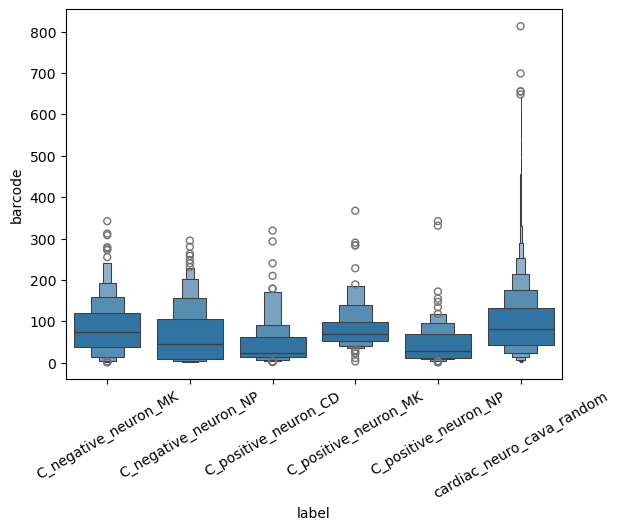

In [17]:
sns.boxenplot(data=assignment_barcode_counts_important_filter, x="label", y="barcode")
plt.xticks(rotation=30)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'C_negative_neuron_MK'),
  Text(1, 0, 'C_negative_neuron_NP'),
  Text(2, 0, 'C_positive_neuron_CD'),
  Text(3, 0, 'C_positive_neuron_MK'),
  Text(4, 0, 'C_positive_neuron_NP'),
  Text(5, 0, 'tested_Element_sequence'),
  Text(6, 0, 'tested_ALT_sequences'),
  Text(7, 0, 'tested_REF_sequences')])

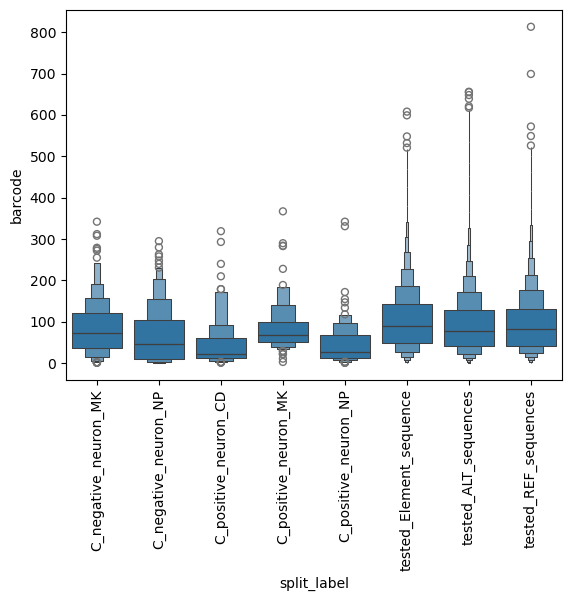

In [16]:
sns.boxenplot(data=assignment_barcode_counts_important_filter, x="split_label", y="barcode")
plt.xticks(rotation=90)
# plt.ylim(0,400)

In [18]:
assignment_barcode_counts_important_filter['barcode'].max()

813

In [19]:
assignment_barcode_counts_important_filter.groupby(["label"]).agg(avg_barcode_count=('barcode','mean'),
                                                 median_barcode_count=('barcode', 'median')).reset_index()

,label,avg_barcode_count,median_barcode_count
0,C_negative_neuron_MK,86.322430,74.0
1,C_negative_neuron_NP,67.195980,46.0
2,C_positive_neuron_CD,47.376344,23.0
3,C_positive_neuron_MK,85.385417,68.5
4,C_positive_neuron_NP,46.808081,27.0
5,cardiac_neuro_cava_random,94.774550,81.0


In [20]:
assignment_barcode_counts_important_filter.groupby(["split_label"]).agg(avg_barcode_count=('barcode','mean'),
                                                 median_barcode_count=('barcode', 'median')).reset_index()

,split_label,avg_barcode_count,median_barcode_count
0,C_negative_neuron_MK,86.322430,74.0
1,C_negative_neuron_NP,67.195980,46.0
2,C_positive_neuron_CD,47.376344,23.0
3,C_positive_neuron_MK,85.385417,68.5
4,C_positive_neuron_NP,46.808081,27.0
5,tested_ALT_sequences,92.961770,79.0
6,tested_Element_sequence,102.654674,89.0
7,tested_REF_sequences,95.471503,82.0


### Create data composition: 

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = ["A1", "A2", "B1", "B2", "C1", "C2"],
      color = "blue"
    ),
    link = dict(
      source = [0, 1, 0, 2, 3, 3], # indices correspond to labels, eg A1, A2, A1, B1, ...
      target = [2, 3, 3, 4, 4, 5],
      value = [8, 4, 2, 8, 4, 2]
  ))])

fig.update_layout(title_text="Basic Sankey Diagram", font_size=10)
fig.show()